In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd import Value 
from nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

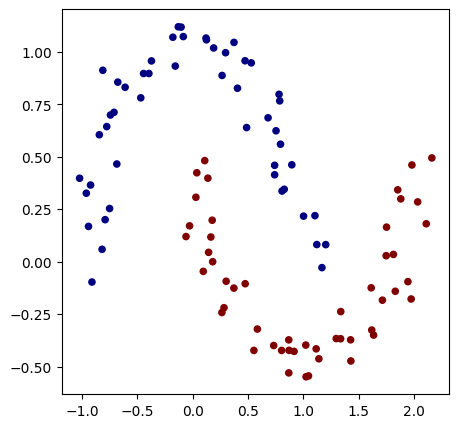

In [4]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [5]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network

model.layers[-1].neurons[0].nonlin = True
model.layers[-1].neurons[0].activation = 'sigmoid' # using sigmoid
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2), reluNeuron(2)], Layer of [reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16), reluNeuron(16)], Layer of [sigmoidNeuron(16)]]
number of parameters 337


In [6]:
def loss(batch_size = None):
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    inputs = [list(map(Value, xrow)) for xrow in Xb]

    scores = list(map(model, inputs))

    # binary cross entropy loss
    losses = [-yt*(yp.log()) - (1-yt)*((1 - yp).log()) for yt, yp in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))

    # L2 regularization to prevent overfitting
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))

    total_loss = data_loss + reg_loss
    accuracy = [(yi > 0) == (scorei.data > 0.5) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)


Value(data=0.690468640952976, grad=0) 0.5


In [7]:
losses = []
steps = []
accuracy = []

In [8]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()

    # logging
    losses.append(total_loss.data)
    steps.append(steps[-1] + 1 if len(steps) else 1)
    accuracy.append(acc)
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.690468640952976, accuracy 50.0%
step 1 loss 1.351891110485839, accuracy 81.0%
step 2 loss 0.37837093744438816, accuracy 81.0%
step 3 loss 0.323292977152511, accuracy 84.0%
step 4 loss 0.29366837979888344, accuracy 86.0%
step 5 loss 0.2829727647891779, accuracy 87.0%
step 6 loss 0.2734912654552134, accuracy 88.0%
step 7 loss 0.26550743131467663, accuracy 88.0%
step 8 loss 0.2592612844840911, accuracy 88.0%
step 9 loss 0.2532553536276309, accuracy 90.0%
step 10 loss 0.24758667538630513, accuracy 91.0%
step 11 loss 0.24201990065793788, accuracy 91.0%
step 12 loss 0.23697441595359467, accuracy 91.0%
step 13 loss 0.23205686404154166, accuracy 91.0%
step 14 loss 0.22705418105987413, accuracy 91.0%
step 15 loss 0.22198324830574676, accuracy 92.0%
step 16 loss 0.21688557009951356, accuracy 92.0%
step 17 loss 0.21227933716227734, accuracy 92.0%
step 18 loss 0.20777417411642607, accuracy 92.0%
step 19 loss 0.20340725719794947, accuracy 92.0%
step 20 loss 0.1993109029333251, accurac

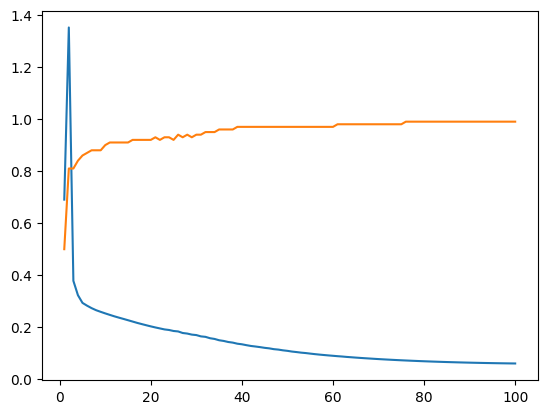

In [9]:
plt.plot(steps, losses)
plt.plot(steps, accuracy)

(-1.548639298268643, 1.951360701731357)

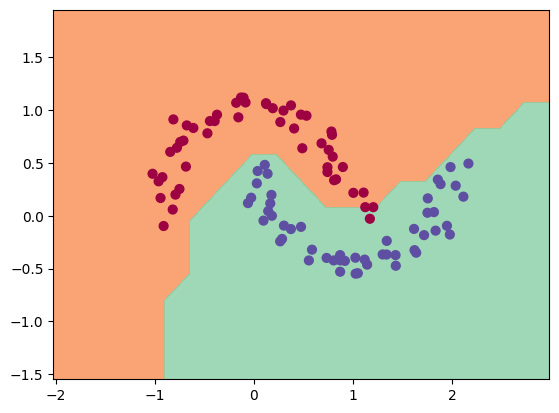

In [12]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0.5 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())